# Cross-Case-Study Temporal Feature Summary

**Docker image**: `ml4t`

**Chapter 9: From Correlation to Causation**
**Section Reference**: 9.7 - Integration and Cross-Asset Comparison

## Purpose

This notebook inventories the temporal features each case study produced -
which model families (GARCH, HMM, Kalman, FFD, ARIMA, ...) appear, how many
features each contributes, and where regime indicators are present. It is a
cross-asset map of *what was built*; the incremental predictive value of these
features is evaluated inside each case study's ML pipeline (Ch11+) against the
results registry, not here.

## Learning Objectives

1. Compare temporal model usage across asset classes (GARCH, HMM, Kalman, FFD, ARIMA)
2. Count how many temporal features each case study contributes, and in which families
3. Locate regime indicators (HMM / regime features) across case studies
4. See where walk-forward temporal features enter the pipeline, before their
   predictive value is measured downstream

## Prerequisites

- Case study temporal notebooks must have produced `features/model_based.parquet`
- If temporal feature data is missing, case studies show as "no temporal features"

In [1]:
"""Cross-case-study temporal feature summary."""

import warnings

import plotly.graph_objects as go
import polars as pl
from IPython.display import display

warnings.filterwarnings("ignore")

from utils.paths import get_case_study_dir

In [2]:
# Scale parameters (Papermill overrides for testing; readers see production values)
START_DATE = None  # use full dataset

## 1. Load Temporal Feature Data

Scan all case study `features/` directories for `model_based.parquet`
produced by the temporal feature notebooks.

In [3]:
CASE_STUDIES = [
    "etfs",
    "crypto_perps_funding",
    "nasdaq100_microstructure",
    "sp500_equity_option_analytics",
    "us_firm_characteristics",
    "fx_pairs",
    "cme_futures",
    "sp500_options",
    "us_equities_panel",
]

DISPLAY_NAMES = {
    "etfs": "ETFs",
    "crypto_perps_funding": "Crypto Perps",
    "nasdaq100_microstructure": "NASDAQ-100",
    "sp500_equity_option_analytics": "S&P 500 Eq+Opt",
    "us_firm_characteristics": "US Firm Chars",
    "fx_pairs": "FX Pairs",
    "cme_futures": "CME Futures",
    "sp500_options": "S&P 500 Options",
    "us_equities_panel": "US Equities",
}

# Columns that are identifiers, not features
_ID_COLS = {"timestamp", "symbol", "product", "stock_id", "instrument_id", "date", "asset"}

# Known temporal model prefixes
_TEMPORAL_MODELS = {
    "hmm": "hmm",
    "garch": "garch",
    "kalman": "kalman",
    "arima": "arima",
    "ffd": "ffd",
    "spectral": "spectral",
    "bayesian": "bayesian_sv",
    "regime": "hmm",
    "vol": "garch",
}


def load_temporal_info(case_study_id: str) -> dict | None:
    """Load temporal feature summary by introspecting model_based.parquet schema."""
    case_dir = get_case_study_dir(case_study_id)
    mb_path = case_dir / "features" / "model_based.parquet"
    if not mb_path.exists():
        return None

    schema = pl.scan_parquet(mb_path).collect_schema()
    feature_names = [c for c in schema.names() if c not in _ID_COLS]
    n_features = len(feature_names)

    # Detect which temporal models are represented
    models_used: dict[str, bool] = {}
    for model_key in ["hmm", "garch", "kalman", "arima", "ffd", "spectral", "bayesian_sv"]:
        models_used[model_key] = any(model_key in f.lower() for f in feature_names)

    # Group by prefix
    family_counts: dict[str, int] = {}
    for name in feature_names:
        parts = name.split("_")
        family = parts[0] if len(parts) > 1 else "other"
        family_counts[family] = family_counts.get(family, 0) + 1

    return {
        "n_temporal_features": n_features,
        "feature_names": feature_names,
        "models_used": models_used,
        "family_counts": family_counts,
    }

In [4]:
# Load all temporal feature info
all_temporal: dict[str, dict] = {}
has_incremental: dict[str, dict] = {}
no_temporal: list[str] = []

for cs in CASE_STUDIES:
    result = load_temporal_info(cs)
    if result is None:
        no_temporal.append(cs)
        continue
    all_temporal[cs] = result
    has_incremental[cs] = result

print(f"Case studies with temporal features: {len(all_temporal)}/{len(CASE_STUDIES)}")
if no_temporal:
    print(f"  No temporal data: {', '.join(DISPLAY_NAMES.get(cs, cs) for cs in no_temporal)}")

Case studies with temporal features: 8/9
  No temporal data: US Firm Chars


## 2. Temporal Model Inventory

Which temporal techniques does each case study use? This table provides
a cross-asset comparison of model choices.

In [5]:
# Extract model inventory from feature name patterns in model_based.parquet
model_inventory = []
known_models = ["hmm", "garch", "kalman", "arima", "ffd", "spectral", "bayesian_sv"]

for cs, result in all_temporal.items():
    row = {"case_study": DISPLAY_NAMES[cs]}
    for model in known_models:
        row[model] = "Y" if result["models_used"].get(model, False) else ""
    row["n_features"] = result["n_temporal_features"]
    model_inventory.append(row)

inv_df = pl.DataFrame(model_inventory)
inv_df

case_study,hmm,garch,kalman,arima,ffd,spectral,bayesian_sv,n_features
str,str,str,str,str,str,str,str,i64
"""ETFs""","""""","""Y""","""""","""""","""Y""","""""","""""",15
"""Crypto Perps""","""Y""","""Y""","""""","""""","""""","""""","""""",6
"""NASDAQ-100""","""""","""""","""""","""""","""""","""Y""","""""",23
"""S&P 500 Eq+Opt""","""""","""Y""","""""","""""","""""","""""","""""",4
"""FX Pairs""","""Y""","""""","""Y""","""Y""","""""","""""","""""",11
"""CME Futures""","""Y""","""""","""""","""Y""","""""","""Y""","""""",11
"""S&P 500 Options""","""""","""Y""","""""","""""","""""","""""","""""",5
"""US Equities""","""""","""Y""","""""","""""","""Y""","""""","""""",10


## 3. Temporal Feature Count by Case Study

How many temporal features does each case study produce?

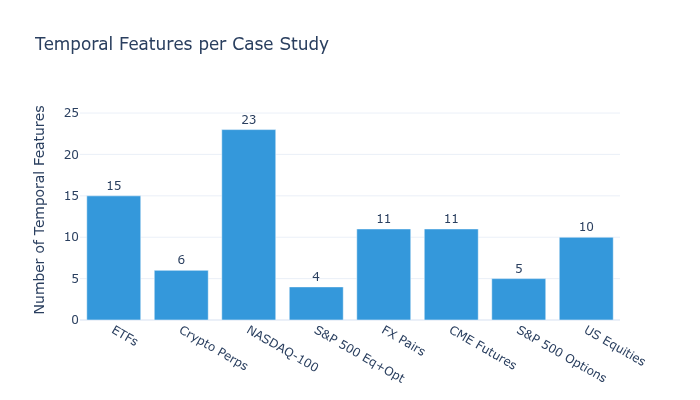

In [6]:
if all_temporal:
    feat_counts = []
    for cs, result in all_temporal.items():
        feat_counts.append(
            {
                "case_study": DISPLAY_NAMES[cs],
                "n_temporal_features": result["n_temporal_features"],
            }
        )

    feat_df = pl.DataFrame(feat_counts).sort("n_temporal_features", descending=True)

    fig = go.Figure(
        go.Bar(
            x=[r["case_study"] for r in feat_counts],
            y=[r["n_temporal_features"] for r in feat_counts],
            marker_color="#3498db",
            text=[str(r["n_temporal_features"]) for r in feat_counts],
            textposition="outside",
        )
    )
    fig.update_layout(
        title="Temporal Features per Case Study",
        yaxis_title="Number of Temporal Features",
        template="plotly_white",
        height=400,
    )
    fig.show()

## 4. Temporal Feature Inventory by Case Study

A representative sample of the temporal feature names each case study produces,
alongside the count of features in each model family. This shows the *shape* of
each case study's temporal feature set. Whether these features add incremental
predictive value is measured in the case study ML pipelines (Ch11+), where their
IC is evaluated against the registry - not in this inventory.

case_study,feature
str,str
"""ETFs""","""fold"""
"""ETFs""","""regime_prob_stress"""
"""ETFs""","""regime_transition"""
"""ETFs""","""regime_log_duration"""
"""ETFs""","""ffd_spy"""
…,…
"""US Equities""","""wass_tail_div"""
"""US Equities""","""ffd_log_price"""
"""US Equities""","""ffd_log_volume"""


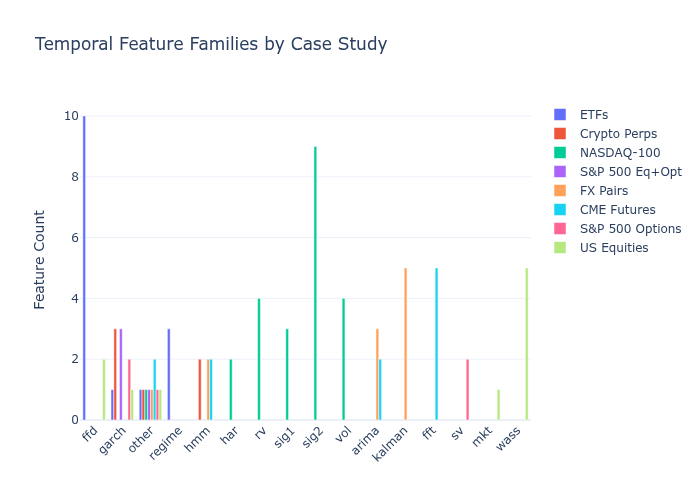

In [7]:
if has_incremental:
    # Show temporal feature names per case study
    incr_rows = []
    for cs, result in has_incremental.items():
        for feat_name in result["feature_names"][:10]:
            incr_rows.append(
                {
                    "case_study": DISPLAY_NAMES[cs],
                    "feature": feat_name,
                }
            )

    if incr_rows:
        incr_df = pl.DataFrame(incr_rows)
        display(incr_df)

        # Bar chart: feature count by family per case study
        fig = go.Figure()
        for cs in has_incremental:
            result = has_incremental[cs]
            families = sorted(result["family_counts"].keys())
            fig.add_trace(
                go.Bar(
                    name=DISPLAY_NAMES[cs],
                    x=families,
                    y=[result["family_counts"][f] for f in families],
                )
            )

        fig.update_layout(
            title="Temporal Feature Families by Case Study",
            yaxis_title="Feature Count",
            template="plotly_white",
            height=500,
            xaxis_tickangle=-45,
            barmode="group",
        )
        fig.show()
    else:
        print("No temporal feature data available.")
else:
    print("No model_based.parquet found. Run case study temporal notebooks first.")

## 5. Regime Detection Comparison

Do stress regimes align across case studies? If HMM-detected stress periods
coincide across asset classes, this suggests common macro drivers.

In [8]:
# Extract regime information from temporal feature names
regime_info = []
for cs, result in all_temporal.items():
    has_hmm = result["models_used"].get("hmm", False)
    # Check for regime-related features
    regime_features = [
        f for f in result["feature_names"] if "regime" in f.lower() or "hmm" in f.lower()
    ]

    regime_info.append(
        {
            "case_study": DISPLAY_NAMES[cs],
            "has_hmm": "Y" if has_hmm else "",
            "n_regime_features": len(regime_features),
        }
    )

regime_df = pl.DataFrame(regime_info)
regime_df

case_study,has_hmm,n_regime_features
str,str,i64
"""ETFs""","""""",3
"""Crypto Perps""","""Y""",2
"""NASDAQ-100""","""""",0
"""S&P 500 Eq+Opt""","""""",0
"""FX Pairs""","""Y""",2
"""CME Futures""","""Y""",2
"""S&P 500 Options""","""""",0
"""US Equities""","""""",0


## 6. Temporal Model Presence by Case Study

Temporal models are prone to lookahead bias, so they are fit walk-forward inside
each case study's cross-validation pipeline - that is where the filtered-vs-smoothed
and point-in-time discipline is enforced and tested. Here we simply record which
temporal models are present per case study as a coverage check.

In [9]:
# Temporal models are all fitted walk-forward within the CV framework (per the pipeline design).
# We note which models are present per case study as a discipline check.
discipline_rows = []
for cs, result in all_temporal.items():
    models = result["models_used"]
    active_models = [m for m, used in models.items() if used]
    discipline_rows.append(
        {
            "case_study": DISPLAY_NAMES[cs],
            "n_temporal_features": result["n_temporal_features"],
            "active_models": ", ".join(active_models) if active_models else "none detected",
        }
    )

disc_df = pl.DataFrame(discipline_rows)
disc_df

case_study,n_temporal_features,active_models
str,i64,str
"""ETFs""",15,"""garch, ffd"""
"""Crypto Perps""",6,"""hmm, garch"""
"""NASDAQ-100""",23,"""spectral"""
"""S&P 500 Eq+Opt""",4,"""garch"""
"""FX Pairs""",11,"""hmm, kalman, arima"""
"""CME Futures""",11,"""hmm, arima, spectral"""
"""S&P 500 Options""",5,"""garch"""
"""US Equities""",10,"""garch, ffd"""


## Summary

This inventory maps the temporal features available to each case study before
their predictive value is measured downstream:

- **Model coverage varies by asset class.** The inventory table (Section 2) shows
  which of GARCH, HMM, Kalman, FFD, ARIMA, spectral, and Bayesian-SV features each
  case study produced; not every model applies to every market.
- **Regime indicators** (HMM / regime-tagged features) appear wherever a case study
  runs an HMM, and feed conditional analysis rather than predicting returns directly.
- **Feature counts** (Section 3) show how much temporal structure each case study
  adds on top of its Ch8 base features.

What this notebook deliberately does **not** claim is the incremental IC of temporal
features. That is evaluated per case study in the ML pipeline (Ch11+) against the
results registry, where base-plus-temporal models are compared to base-only models
on held-out data. Chapter 9.7 discusses temporal feature integration and the risk of
adding complexity without proportional predictive improvement; the case study results
are what quantify whether that risk paid off.

**Next**: case study pipelines (Ch11+) fit models on combined base + temporal
features and record their evaluation in the registry.